# Libraries

In [1]:
from graph_creation import create_mesh_dataset, save_database, create_dataset_folders

In [ ]:
create_dataset_folders(dataset_folder='datasets')

# Create and save pytorch geometric dataset

In [ ]:
# dataset_folder, dataset_name, dataset_dir, with_multiscale, start_sim_id, n_sim
simulation_ids = [
    # ['./raw_datasets_mesh', 'mesh_dataset2','datasets/train', False, range(1, 1+80)],
    # ['./raw_datasets_mesh', 'mesh_dataset2','datasets/test', False, range(81, 81+20)],
    # ['./raw_datasets_mesh', 'multiscale_mesh_dataset2','datasets/train', True, range(1, 1+80)],
    # ['./raw_datasets_mesh', 'multiscale_mesh_dataset2','datasets/test', True, range(81, 81+1)],
    # ['./raw_datasets_dk15', 'dijkring_15_big','datasets/test', True, range(101, 101+11)],
    # ['./raw_datasets_dk15', 'dijkring_15_big_fine','datasets/test', False, range(101, 101+1)],
    # ['./raw_datasets_dyce', 'dyce_lisfloodfp_cpu_highflow1', 'datasets/train', True, [0, 1, 3, 4, 7 , 9, 10, 11, 12]],
    # ['./raw_datasets_dyce', 'dyce_lisfloodfp_cpu_highflow2', 'datasets/train', True, [13, 15, 16, 18, 19, 21, 22, 23, 25]],
    # ['./raw_datasets_dyce', 'dyce_lisfloodfp_cpu_highflow3', 'datasets/train', True, [26, 28, 29, 30, 32, 33, 34, 36, 37]],
    # ['./raw_datasets_dyce', 'dyce_lisfloodfp_cpu_highflow4', 'datasets/train', True, [38, 39, 40, 42, 43, 44, 45, 46, 47]],
    ['./raw_datasets_dyce', 'dyce_lisfloodfp_cpu_highflow1test', 'datasets/test', True, [2, 5, 6, 8, 14, 17, 20, 24]],
    ['./raw_datasets_dyce', 'dyce_lisfloodfp_cpu_highflow2test', 'datasets/test', True, [27, 31, 35, 41, 48, 49, 50, 51]],
]

In [ ]:
for dataset_folder, dataset_name, dataset_dir, with_multiscale, sim_ids in simulation_ids:
   # sim_ids = range(start_sim_id, start_sim_id+n_sim)
   mesh_dataset = create_mesh_dataset(dataset_folder, sim_ids=sim_ids,
                                      with_multiscale=with_multiscale, number_of_multiscales=5,
                                      netcdf_file_template='hydrograph_{:04}_highflow.nc.zst', DEM_file_template='dyce_lisfloodfp.xyz',
                        hydrograph_file_template='hydrograph_{:04}_highflow.txt', polygon_file_template='dyce_polygon.pol'
                                      )
   
   if dataset_name[:8] == 'dijkring':
      train_dataset = [mesh_dataset[0]]
      test_dataset = mesh_dataset[1:]
      save_database(train_dataset, name=dataset_name, out_path='datasets/train')
      save_database(test_dataset, name=dataset_name, out_path='datasets/test')
   else:
      save_database(mesh_dataset, name=dataset_name, out_path=dataset_dir)

##############


In [ ]:
h2 = pickle.load(open("datasets/train/dyce/hydrograph_0002_highflow.pkl", "rb"))
h5 = pickle.load(open("datasets/train/dyce/hydrograph_0005_highflow.pkl", "rb"))

In [ ]:
h2.keys()

In [ ]:
import pickle
meshes = pickle.load(open("raw_datasets_dyce/dyce_mesh.pkl", "rb"))

In [ ]:
import xarray as xr
nc_dataset = xr.open_dataset("raw_datasets_dyce/Simulations/hydrograph_0005_highflow.zarr")
WD = nc_dataset['mesh2d_waterdepth'].data.T

In [ ]:
WD.shape

In [ ]:
mesh_dataset[0].WD.shape

ZARR Dataset Creation

In [218]:
import importlib
import graph_creation
importlib.reload(graph_creation)
from graph_creation import export_zarr_dataset, MultiscaleMesh

In [249]:
mesh_with_ghost_cells.face_xy[5457]

array([389715.53374906, 813145.06641518])

In [18]:
mesh.edge_index_BC

array([[20952, 86112],
       [74739,  5457]], dtype=int32)

In [30]:
mesh.face_nodes.max()

87056

In [219]:
import copy
from graph_creation import Mesh, add_ghost_cells_mesh
import xarray as xr

netcdf_file = "raw_datasets_dyce/../hydrograph_0000_lowflow_3meshed_extraBC.zarr"
DEM_file = "raw_datasets_dyce/DEM/dyce_lisfloodfp.xyz"
nc_dataset = xr.open_dataset(netcdf_file)

mesh = Mesh()
mesh._import_from_map_netcdf(netcdf_file)

# mesh_with_dem = copy.deepcopy(mesh)
mesh._import_DEM(DEM_file)
# mesh_with_ghost_cells = copy.deepcopy(mesh_with_dem)
add_ghost_cells_mesh(mesh)

/home/aidan/.local/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/aidan/.local/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/aidan/.local/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/aidan/.local/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__ini

mesh.face_BC: [124286  31993], len(mesh.face_BC): 2
i: 0, mesh.edge_index_BC: [[20952 86112]
 [74739  5457]], mesh.ghost_node_ids: [87057, 87058], ghost_nodes: [1 1]
mesh.edge_index_BC[i,1]: 86112
i+ghost_nodes[:i+1].sum()-1: 0
mesh.ghost_node_ids[i+ghost_nodes[:i+1].sum()-1]: 87057
i: 1, mesh.edge_index_BC: [[20952 86112]
 [74739  5457]], mesh.ghost_node_ids: [87057, 87058], ghost_nodes: [1 1]
mesh.edge_index_BC[i,1]: 5457
i+ghost_nodes[:i+1].sum()-1: 2
mesh.ghost_node_ids[i+ghost_nodes[:i+1].sum()-1]: 87058
ghost_edge_index: [[87057, 20952], [86112, 87057], [87058, 74739], [5457, 87058]], ghost_face_nodes: [[87057, 20952, 86112], [87058, 74739, 5457]]


Mesh object with 87059 nodes, 260116 edges, 173058 faces, and 518114 dual edges

In [222]:
import numpy as np
import pickle

edge_BC_mid = mesh.node_xy[mesh.edge_index_BC].mean(1)

with open("raw_datasets_dyce/dyce_mesh.pkl", "rb") as f:
    meshes = pickle.load(f)

for mesh in copy.copy(meshes[:6]):
    is_there_edge_BC = np.full(edge_BC_mid.shape[0], False)
    # top_n is the number of closest nodes to consider for each edge midpoint
    top_n = 2

    mesh.edge_index_BC = np.full((edge_BC_mid.shape[0], 2), -1)

    while not is_there_edge_BC.all():
        print(f"top_n: {top_n}, is_there_edge_BC: {is_there_edge_BC}, mesh.edge_index_BC: {mesh.edge_index_BC}")
        if top_n > 10:
            raise ValueError('No edge found')
        possible_edges = np.array([graph_creation.find_closest_nodes(mesh.node_xy, edge, top_n=top_n) for edge in edge_BC_mid]) # For each point in edge_BC_mid for which a boundary edge hasn't been found, find top n closest nodes
        print(f"possible_edges: {possible_edges}")
        print([[node for node in edge if mesh.node_xy[node] in mesh.boundary_nodes] for edge in possible_edges])
        edge_index_BC = [[node for node in edge if mesh.node_xy[node] in mesh.boundary_nodes] for edge in possible_edges] # Using "in" is less efficient, but the prior solution failed if any of the boundary nodes had common x or y coordinates
        for i in range(len(edge_index_BC)):
            if len(edge_index_BC[i]) == 2:
                mesh.edge_index_BC[i] = edge_index_BC[i]
        # mesh.edge_index_BC = np.array([[node for node in edge if mesh.node_xy[node] in mesh.boundary_nodes] for edge in possible_edges]) # For each point in edge_BC_mid for which a boundary edge hasn't been found, find the closest nodes that are also boundary nodes
        print(f"New mesh.edge_index_BC: {mesh.edge_index_BC}")
        mesh.edge_BC = np.array([np.where(((edge == mesh.edge_index.T).sum(1) == 2) | 
                                        ((edge[::-1] == mesh.edge_index.T).sum(1) == 2))[0] or [-1]
                                        for edge in mesh.edge_index_BC]).reshape(-1) # Compute edge_BC (index of the boundary edge) from edge_index_BC (index of the two nodes that form the boundary edge)
        print(f"mesh.edge_BC: {mesh.edge_BC}")
        # if mesh.edge_BC.shape[0] == 1:
        #     is_there_edge_BC = True
        is_there_edge_BC = mesh.edge_BC != -1
        
        top_n += 1
    
    mesh.edge_type[mesh.edge_BC] = 2
    mesh.face_BC = graph_creation.find_face_BC(mesh)

    # overwrite edge_BC_mid to ensure that the ghost cells don't derail in the coarse meshes
    edge_BC_mid = mesh.node_xy[mesh.edge_index_BC].mean(1)

top_n: 2, is_there_edge_BC: [False False], mesh.edge_index_BC: [[-1 -1]
 [-1 -1]]
possible_edges: [[30  0]
 [15 14]]
[[30, 0], [15, 14]]
New mesh.edge_index_BC: [[30  0]
 [15 14]]
mesh.edge_BC: [102 194]
top_n: 2, is_there_edge_BC: [False False], mesh.edge_index_BC: [[-1 -1]
 [-1 -1]]
possible_edges: [[204 201]
 [296 291]]
[[204], [296]]
New mesh.edge_index_BC: [[-1 -1]
 [-1 -1]]
mesh.edge_BC: [-1 -1]
top_n: 3, is_there_edge_BC: [False False], mesh.edge_index_BC: [[-1 -1]
 [-1 -1]]
possible_edges: [[204 201  30]
 [296 291  15]]
[[204, 30], [296, 15]]
New mesh.edge_index_BC: [[204  30]
 [296  15]]
mesh.edge_BC: [879 194]
top_n: 2, is_there_edge_BC: [False False], mesh.edge_index_BC: [[-1 -1]
 [-1 -1]]
possible_edges: [[1251   30]
 [ 566  296]]
[[1251, 30], [566, 296]]
New mesh.edge_index_BC: [[1251   30]
 [ 566  296]]
mesh.edge_BC: [3954 3269]
top_n: 2, is_there_edge_BC: [False False], mesh.edge_index_BC: [[-1 -1]
 [-1 -1]]
possible_edges: [[5373 1251]
 [4688  296]]
[[5373, 1251], [4688

/tmp/ipykernel_1377/3688998267.py:29: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  mesh.edge_BC = np.array([np.where(((edge == mesh.edge_index.T).sum(1) == 2) |


top_n: 2, is_there_edge_BC: [False False], mesh.edge_index_BC: [[-1 -1]
 [-1 -1]]
possible_edges: [[ 9495  5373]
 [21044  4688]]
[[9495, 5373], [21044, 4688]]
New mesh.edge_index_BC: [[ 9495  5373]
 [21044  4688]]
mesh.edge_BC: [52758 15503]
top_n: 2, is_there_edge_BC: [False False], mesh.edge_index_BC: [[-1 -1]
 [-1 -1]]
possible_edges: [[74655  9495]
 [37400 21044]]
[[74655, 9495], [37400, 21044]]
New mesh.edge_index_BC: [[74655  9495]
 [37400 21044]]
mesh.edge_BC: [ 52758 210455]


In [195]:
graph_creation.find_face_BC(mesh)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

array([[ 0, 30],
       [15, 14]])

In [217]:
getfacenodesmesh[32]

array([14., 31., 15.])

In [199]:
getfacenodesmesh

array([[  0.,  58.,   1.],
       [  0.,  30.,  58.],
       [  1.,  58.,  42.],
       [  1.,  42.,   2.],
       [  2.,  42.,  41.],
       [  2.,  41.,   3.],
       [  3.,  41.,   4.],
       [  4.,  43.,  45.],
       [  4.,  45.,   5.],
       [  4.,  41.,  43.],
       [  5.,  97.,   6.],
       [  5.,  45.,  46.],
       [  5.,  46.,  97.],
       [  6.,  97.,  99.],
       [  6.,  99.,  85.],
       [  6.,  85.,   7.],
       [  7.,  66.,   8.],
       [  7.,  85.,  84.],
       [  7.,  84.,  66.],
       [  8.,  64.,   9.],
       [  8.,  66.,  64.],
       [  9.,  64.,  59.],
       [  9.,  59.,  10.],
       [ 10.,  59.,  76.],
       [ 10.,  76.,  11.],
       [ 11.,  76.,  75.],
       [ 11.,  75.,  51.],
       [ 12.,  51.,  36.],
       [ 12.,  36.,  35.],
       [ 12.,  35.,  32.],
       [ 13.,  32.,  31.],
       [ 13.,  31.,  14.],
       [ 14.,  31.,  15.],
       [ 15.,  31.,  33.],
       [ 15.,  33.,  16.],
       [ 16.,  33.,  98.],
       [ 16.,  98.,  17.],
 

In [105]:
possible_edges

array([[ 0, 58],
       [15, 14]])

In [104]:
[[node for node in edge if mesh.node_xy[node] in mesh.boundary_nodes] for edge in possible_edges]

[[0], [15, 14]]

In [100]:
possible_edges = np.array([graph_creation.find_closest_nodes(mesh.node_xy, edge, top_n=5) for edge in edge_BC_mid])
possible_edges

array([[ 0, 30, 58, 39,  1],
       [15, 31, 14, 33, 13]])

In [94]:
edge_BC_mid

array([[388906.45933 , 814098.791275],
       [390405.52183 , 809919.8069  ]])

In [88]:
possible_edges

array([[ 0, 30, 58, 39,  1],
       [15, 31, 14, 33, 13]])

In [102]:
for node in possible_edges.flatten():
    print(node, (mesh.node_xy[node] == mesh.boundary_nodes).sum(), (mesh.node_xy[node] == mesh.boundary_nodes).sum()==2)
    print(mesh.node_xy[node] in mesh.boundary_nodes)
    print(node)

0 2 True
True
0
30 12 False
True
30
58 0 False
False
58
39 0 False
False
39
1 2 True
True
1
15 2 True
True
15
31 0 False
False
31
14 3 False
True
14
33 0 False
False
33
13 3 False
True
13


In [107]:
possible_edges

array([[ 0, 58],
       [15, 14]])

In [179]:
mesh.edge_index.T[194]

array([15, 14], dtype=int32)

IndexError: index 194 is out of bounds for axis 0 with size 169

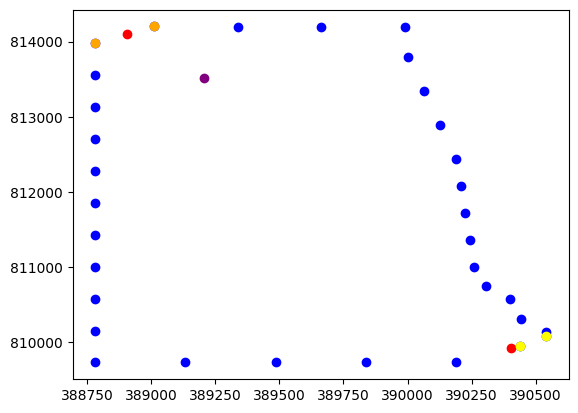

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(mesh.boundary_nodes[:,0], mesh.boundary_nodes[:,1], c="blue")
plt.scatter(edge_BC_mid[:,0], edge_BC_mid[:,1], c="red")
# plt.scatter(mesh.node_xy[possible_edges.flatten()][:,0], mesh.node_xy[possible_edges.flatten()][:,1], c="green")
plt.scatter(mesh.node_xy[[0, 30]][:,0], mesh.node_xy[[0,30]][:,1], c="orange")
plt.scatter(mesh.node_xy[[15, 14]][:,0], mesh.node_xy[[15,14]][:,1], c="yellow")
plt.show()

In [31]:
(mesh.node_xy[13] == mesh.boundary_nodes)

array([[False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [ True,  True],
       [ True, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False]])

In [16]:
print(mesh.face_x[ graph_creation.get_face_nodes_mesh(mesh)[5457].astype(int) ])

[389156.97350674 389017.0049742  390085.05413882]


In [213]:
dual_edge_index = nc_dataset['mesh2d_edge_faces'].data.T.astype(int) - 1
face_bnd_mask = dual_edge_index[0,:] == -1 # BC edge
face_BC = dual_edge_index[1,face_bnd_mask]
extra_face_bnd_mask = dual_edge_index[1,:] == -1
face_bnd = dual_edge_index[0,extra_face_bnd_mask]
total_face_bnd_mask = extra_face_bnd_mask | face_bnd_mask

In [214]:
import numpy as np
mesh = mesh_with_ghost_cells

the_other_node = graph_creation.find_BC_other_nodes(mesh)

face_BC_xy = mesh.face_xy[mesh.face_BC]
node_BC_xy = mesh.node_xy[the_other_node]

# faces are mirrored w.r.t. edge center
face_symmetry_point = mesh.node_xy[mesh.edge_index_BC].mean(1)

edge_outward_normal_faces = mesh.edge_outward_normal[mesh.edge_BC]

# nodes are mirrored w.r.t. edge center (triangles) or edge nodes (quatrilaterals)
node_symmetry_point = np.concatenate([item.mean(0) if mesh.nodes_per_face[mesh.face_BC][i] == 3
                                else item for i, item in enumerate(mesh.node_xy[mesh.edge_index_BC])]).reshape(-1,2)

edge_outward_normal_nodes = np.concatenate([np.repeat(item.reshape(1,-1), 2, axis=0) if mesh.nodes_per_face[mesh.face_BC][i] == 4
                                else item for i, item in enumerate(mesh.edge_outward_normal[mesh.edge_BC])]).reshape(-1,2)

distance_face_edge_BC = np.linalg.norm((face_BC_xy - face_symmetry_point), axis=1).reshape(-1,1)
distance_node_edge_BC = np.linalg.norm((node_BC_xy - node_symmetry_point), axis=1).reshape(-1,1)

normal_adapter = np.int32([1, 0])
ghost_face_BC_xy = face_symmetry_point - edge_outward_normal_faces[:,normal_adapter]*distance_face_edge_BC
ghost_node_BC_xy = node_symmetry_point - edge_outward_normal_nodes[:,normal_adapter]*distance_node_edge_BC

distance_node_ghost_BC = np.linalg.norm((node_BC_xy - ghost_node_BC_xy), axis=1).reshape(-1,1)

# The ghost nodes are not mirrored correctly so we flip the normal
if (distance_node_ghost_BC < distance_node_edge_BC).any():
    edge_outward_normal_faces[:,(distance_node_ghost_BC < distance_node_edge_BC).squeeze()] *= -1
    edge_outward_normal_nodes[:,(distance_node_ghost_BC < distance_node_edge_BC).squeeze()] *= -1

    ghost_face_BC_xy = face_symmetry_point - edge_outward_normal_faces[:,normal_adapter]*distance_face_edge_BC
    ghost_node_BC_xy = node_symmetry_point - edge_outward_normal_nodes[:,normal_adapter]*distance_node_edge_BC

mesh.node_x = np.concatenate((mesh.node_x, ghost_node_BC_xy[:,0]))
mesh.node_y = np.concatenate((mesh.node_y, ghost_node_BC_xy[:,1]))

mesh.face_x = np.concatenate((mesh.face_x, ghost_face_BC_xy[:,0]))
mesh.face_y = np.concatenate((mesh.face_y, ghost_face_BC_xy[:,1]))

mesh.nodes_per_face = np.concatenate((mesh.nodes_per_face, mesh.nodes_per_face[mesh.face_BC]))

# update edge_index and dual_edge_index after adding ghost cells
# dual_edge_index is converted to undirected
mesh.dual_edge_index_BC, mesh.ghost_cells_ids = graph_creation.get_BC_edge_index(mesh.dual_edge_index, 
                                                        mesh.face_BC, undirected_BC=False)
mesh.dual_edge_index = np.concatenate((mesh.dual_edge_index, mesh.dual_edge_index_BC), 1)
ghost_edge_index, ghost_face_nodes = graph_creation.get_ghost_nodes(mesh)

mesh.face_BC: [124286  31993], len(mesh.face_BC): 2
ghost_nodes: [1 1]
i: 0, mesh.edge_index_BC: [[20952 86112]
 [74739  5457]], mesh.ghost_node_ids: [87057, 87058], ghost_nodes: [1 1]
mesh.edge_index_BC[i,1]: 86112
i+ghost_nodes[:i+1].sum()-1: 0
mesh.ghost_node_ids[i+ghost_nodes[:i+1].sum()-1]: 87057
i: 1, mesh.edge_index_BC: [[20952 86112]
 [74739  5457]], mesh.ghost_node_ids: [87057, 87058], ghost_nodes: [1 1]
mesh.edge_index_BC[i,1]: 5457
i+ghost_nodes[:i+1].sum()-1: 2


IndexError: list index out of range

In [220]:
node_symmetry_point

array([[388906.45933 , 814098.791275],
       [390405.52183 , 809919.8069  ]])

In [210]:
mesh.node_x.shape

(87059,)

In [199]:
print(mesh.dual_edge_index_BC, mesh.ghost_cells_ids )

[[173056 173057]
 [124286  31993]] [173056 173057]


In [221]:
num_BC_faces = len(mesh.face_BC)
ghost_edge_index = []
ghost_face_nodes = []
ghost_nodes = mesh.nodes_per_face[mesh.face_BC]-2
mesh.ghost_node_ids = [mesh.node_x.shape[0]-j-1 for j in range(ghost_nodes.sum())][::-1]
print(f"ghost_nodes: {ghost_nodes}")
print(f"mesh.ghost_node_ids: {mesh.ghost_node_ids}")

i=0
ghost_edge_index.append([mesh.ghost_node_ids[i], mesh.edge_index_BC[i,0]])
print(f"i: {i}, mesh.edge_index_BC: {mesh.edge_index_BC}, mesh.ghost_node_ids: {mesh.ghost_node_ids}, ghost_nodes: {ghost_nodes}")
print(f"mesh.edge_index_BC[i,1]: {mesh.edge_index_BC[i,1]}")
print(f"i+ghost_nodes[:i+1].sum()-1: {i+ghost_nodes[:i+1].sum()-1}")
print(f"mesh.ghost_node_ids[i+ghost_nodes[:i+1].sum()-1]: {mesh.ghost_node_ids[i+ghost_nodes[:i+1].sum()-1]}")
ghost_edge_index.append([mesh.edge_index_BC[i,1], mesh.ghost_node_ids[i+ghost_nodes[:i+1].sum()-1]])
ghost_face_nodes = mesh.ghost_node_ids[::-1] + mesh.edge_index_BC[i].tolist()

ghost_nodes: [1 1]
mesh.ghost_node_ids: [87057, 87058]
i: 0, mesh.edge_index_BC: [[20952 86112]
 [74739  5457]], mesh.ghost_node_ids: [87057, 87058], ghost_nodes: [1 1]
mesh.edge_index_BC[i,1]: 86112
i+ghost_nodes[:i+1].sum()-1: 0
mesh.ghost_node_ids[i+ghost_nodes[:i+1].sum()-1]: 87057


In [ ]:
mesh.edge_index.max()

Mesh object with 87059 nodes, 260112 edges, 173058 faces, and 518114 dual edges

In [237]:
ghost_edge_index

[[87057, 20952], [86112, 87057]]

In [228]:
mesh.edge_index_BC

array([[20952, 86112],
       [74739,  5457]], dtype=int32)

In [227]:
mesh.ghost_node_ids

[87057, 87058]

In [239]:
ghost_edge_index

[[87057, 20952], [86112, 87057], [87058, 74739]]

In [197]:
print(mesh.node_x[ghost_face_nodes], mesh.node_y[ghost_face_nodes])

[390410.0340879  388899.59157915 388910.05308    388902.86558   ] [809914.67933421 814105.81164253 814102.3069     814095.27565   ]


In [238]:
i=1
ghost_edge_index.append([mesh.ghost_node_ids[i], mesh.edge_index_BC[i,0]])
print(f"i: {i}, mesh.edge_index_BC: {mesh.edge_index_BC}, mesh.ghost_node_ids: {mesh.ghost_node_ids}, ghost_nodes: {ghost_nodes}")
print(f"mesh.edge_index_BC[i,1]: {mesh.edge_index_BC[i,1]}")
print(f"i+ghost_nodes[:i+1].sum()-1: {i+ghost_nodes[:i+1].sum()-1}")
print(f"mesh.ghost_node_ids[i+ghost_nodes[:i+1].sum()-1]: {mesh.ghost_node_ids[i+ghost_nodes[:i+1].sum()-1]}")
ghost_edge_index.append([mesh.edge_index_BC[i,1], mesh.ghost_node_ids[i+ghost_nodes[:i+1].sum()-1]])
ghost_face_nodes = mesh.ghost_node_ids[::-1] + mesh.edge_index_BC[i].tolist()

i: 1, mesh.edge_index_BC: [[20952 86112]
 [74739  5457]], mesh.ghost_node_ids: [87057, 87058], ghost_nodes: [1 1]
mesh.edge_index_BC[i,1]: 5457
i+ghost_nodes[:i+1].sum()-1: 2


IndexError: list index out of range

In [223]:
sim_id = 0
mesh_dataset = create_mesh_dataset(
    "raw_datasets_dyce", sim_ids=[sim_id],
    with_multiscale=True, number_of_multiscales=1,
    netcdf_file_template='../../hydrograph_{:04}_lowflow_3meshed_extraBC.zarr', DEM_file_template='dyce_lisfloodfp.xyz',
    hydrograph_file_template='hydrograph_{:04}_lowflow.txt', polygon_file_template='dyce_polygon.pol',
    multiscale_mesh_file=None, raw_meshes_file="raw_datasets_dyce/dycecut_mesh.pkl"
)
save_database(mesh_dataset[0], name=f"hydrograph_{sim_id:04}_lowflow_1meshed_cut", out_path="datasets/train/dyce/", zarr_output=False)

  0%|          | 0/1 [00:00<?, ?it/s]/home/aidan/.local/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/aidan/.local/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/aidan/.local/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/aidan/.local/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other 

mesh.face_BC: [124286  31993], len(mesh.face_BC): 2
i: 0, mesh.edge_index_BC: [[20952 86112]
 [74739  5457]], mesh.ghost_node_ids: [87057, 87058], ghost_nodes: [1 1]
mesh.edge_index_BC[i,1]: 86112
i+ghost_nodes[:i+1].sum()-1: 0
mesh.ghost_node_ids[i+ghost_nodes[:i+1].sum()-1]: 87057
i: 1, mesh.edge_index_BC: [[20952 86112]
 [74739  5457]], mesh.ghost_node_ids: [87057, 87058], ghost_nodes: [1 1]
mesh.edge_index_BC[i,1]: 5457
i+ghost_nodes[:i+1].sum()-1: 2
mesh.ghost_node_ids[i+ghost_nodes[:i+1].sum()-1]: 87058
ghost_edge_index: [[87057, 20952], [86112, 87057], [87058, 74739], [5457, 87058]], ghost_face_nodes: [[87057, 20952, 86112], [87058, 74739, 5457]]


/home/aidan/.local/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/aidan/.local/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


mesh.face_BC: [ 31993 124286], len(mesh.face_BC): 2
i: 0, mesh.edge_index_BC: [[20952 86112]
 [ 5457 74739]], mesh.ghost_node_ids: [87057, 87058], ghost_nodes: [1 1]
mesh.edge_index_BC[i,1]: 86112
i+ghost_nodes[:i+1].sum()-1: 0
mesh.ghost_node_ids[i+ghost_nodes[:i+1].sum()-1]: 87057
i: 1, mesh.edge_index_BC: [[20952 86112]
 [ 5457 74739]], mesh.ghost_node_ids: [87057, 87058], ghost_nodes: [1 1]
mesh.edge_index_BC[i,1]: 74739
i+ghost_nodes[:i+1].sum()-1: 2
mesh.ghost_node_ids[i+ghost_nodes[:i+1].sum()-1]: 87058
ghost_edge_index: [[87057, 20952], [86112, 87057], [87058, 5457], [74739, 87058]], ghost_face_nodes: [[87057, 20952, 86112], [87058, 5457, 74739]]
mesh.face_BC: [   13 23173], len(mesh.face_BC): 2
i: 0, mesh.edge_index_BC: [[16387  4003]
 [    6 16560]], mesh.ghost_node_ids: [16577, 16578], ghost_nodes: [1 1]
mesh.edge_index_BC[i,1]: 4003
i+ghost_nodes[:i+1].sum()-1: 0
mesh.ghost_node_ids[i+ghost_nodes[:i+1].sum()-1]: 16577
i: 1, mesh.edge_index_BC: [[16387  4003]
 [    6 16560]]

100%|██████████| 1/1 [01:23<00:00, 83.67s/it]


In [ ]:
import pickle
new_mesh = pickle.load(open(f"datasets/train/dyce/hydrograph_{sim_id:04}_lowflow_1meshed_cut.pkl","rb"))
delattr(new_mesh, "WD")
delattr(new_mesh, "VX")
delattr(new_mesh, "VY")
delattr(new_mesh, "BC")
pickle.dump(new_mesh, open("raw_datasets_dyce/dataset_dycecut_1mesh.pkl","wb"))

In [ ]:
# for dataset_folder, dataset_name, dataset_dir, with_multiscale, sim_ids in simulation_ids:
#     for sim_id in sim_ids:
#         print(f"hydrograph_{sim_id:04}_highflow")
#         mesh_dataset = create_mesh_dataset(
#             dataset_folder, sim_ids=[sim_id],
#             with_multiscale=with_multiscale, number_of_multiscales=5,
#             netcdf_file_template='hydrograph_{:04}_highflow.zarr', DEM_file_template='dyce_lisfloodfp.xyz',
#             hydrograph_file_template='hydrograph_{:04}_highflow.txt', polygon_file_template='dyce_polygon.pol',
#             multiscale_mesh_file="./raw_datasets_dyce/dyce_mesh.pkl"
#         )
#         save_database(mesh_dataset[0], name=f"hydrograph_{sim_id:04}_highflow", out_path="datasets/train/dyce/", zarr_output=True)

##############
from graph_creation import add_ghost_cells_attributes, export_zarr_dataset, pool_multiscale_attributes
import pickle
import torch

for dataset_folder, dataset_name, dataset_dir, with_multiscale, sim_ids in simulation_ids:
    data = pickle.load(open("./raw_datasets_dyce/dataset_dyce.pkl", "rb"))
    for sim_id in sim_ids:
        print(f"hydrograph_{sim_id:04}_highflow")
        simulation_dataset = xr.open_dataset(f"./raw_datasets_dyce/Simulations_6meshes/hydrograph_{sim_id:04}_highflow.zarr")

        WD = simulation_dataset['mesh2d_waterdepth'].data.T
        VX = simulation_dataset['mesh2d_ucx'].data.T
        VY = simulation_dataset['mesh2d_ucy'].data.T
        
        BC = np.loadtxt(f"./raw_datasets_dyce/Hydrograph/hydrograph_{sim_id:04}_highflow.txt")
        BC[:,0] /= 60 # convert to minutes
        BC = torch.FloatTensor(BC).unsqueeze(0).repeat(len(data.node_BC), 1, 1) # This repeats the same BC
        
        DEM = data.mesh.DEM
        DEM, WD, VX, VY = add_ghost_cells_attributes(data.mesh.meshes[0], DEM, WD, VX, VY) # Was originally immediately before mesh.stack_meshes(meshes), but placing it here is logically equivalent
        DEM, WD, VX, VY = pool_multiscale_attributes(data.mesh, DEM, WD, VX, VY, reduce='mean')

        export_zarr_dataset({"WD":WD, "VX":VX, "VY":VY, "BC":BC}, path=f"datasets/train/dyce/hydrograph_{sim_id:04}_highflow.zarr")
        # save_database(mesh_dataset[0], name=f"hydrograph_{sim_id:04}_highflow", out_path="datasets/train/dyce/", zarr_output=True)

In [ ]:
mesh_dataset

In [ ]:
dataset = {"WD":WD, "VX":VX, "VY":VY, "BC":BC}
zarr_dataset = xr.Dataset({
    var: xr.DataArray(dataset[var]).rename({"dim_1":"time"}) for var in ["WD","VX","VY","BC"]
})

In [ ]:
import pickle
pickle.dump(mesh_dataset[0], open("hydrograph_0002_highflow.pkl", "wb" ))

In [ ]:
import sys

import torch
for k in mesh_dataset[0].keys():
    # Print the storage of each PyTorch tensor:
    if isinstance(mesh_dataset[0][k], torch.Tensor):
        print(f"{k}: {mesh_dataset[0][k].storage().size() / 1024:.2f} kB")
    else:
        print(f"{k}: Not a PyTorch tensor, type: {type(mesh_dataset[0][k])}")

In [ ]:
mesh_dataset[0]

In [ ]:
for attr in dir(mesh_dataset[0].mesh.meshes[0]):
    print(attr, sys.getsizeof(getattr(mesh_dataset[0].mesh.meshes[0], attr)))